In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('../../data/processed/final_EDA_df.csv')

In [4]:

# 1. 먼저 '거래날짜' 컬럼을 날짜 형식으로 변환 (가장 중요!)
df['거래날짜'] = pd.to_datetime(df['거래날짜'])

# 2. 날짜 형식인 상태에서 가장 최근 날짜(Maximum) 확인
max_date = df['거래날짜'].max()

# 3. 이제 날짜 객체이므로 1년 전 날짜 계산이 가능합니다.
start_date = max_date - pd.DateOffset(years=1)

# 4. 1년치 데이터만 필터링
filtered_df = df[df['거래날짜'] >= start_date].reset_index(drop=True)

print(f"최근 날짜: {max_date}")
print(f"시작 날짜 (1년 전): {start_date}")
print(filtered_df)


최근 날짜: 2020-09-22 00:00:00
시작 날짜 (1년 전): 2019-09-22 00:00:00
                                                       고객ID  패션뉴스구독여부  \
0         00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       0.0   
1         00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       0.0   
2         00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       0.0   
3         00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       0.0   
4         00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       0.0   
...                                                     ...       ...   
14905790  ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...       1.0   
14905791  ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...       1.0   
14905792  ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...       1.0   
14905793  ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...       1.0   
14905794  ffffd9ac14e89946416d80e791d064701994755c3ab686...       0.0   

               멤버십상태   뉴스레터수신빈도    연령         구매일        가격  \

In [4]:
# 머신러닝용 연, 월 컬럼 추가 
df['연'] = df['구매일'].str.split('-').str[0]
df['월'] = df['구매일'].str.split('-').str[1]

# 더미 변수 생성 (멤버십상태,뉴스레터수신빈도, 연령대,  )
# pd.get_dummies(df, columns=['멤버십상태'],dtype=int,drop_first=True) # 아이스크림 맛이 세 가지입니다. 즉, 더미 변수가 두 개 필요합니다. 그중 한 가지 맛을 제외하고 기준선으로 설정


In [5]:
df

,고객ID,패션뉴스구독여부,멤버십상태,뉴스레터수신빈도,연령,구매일,구매금액,상품그룹,연령대,거래날짜,...,전체고객이탈여부,신규고객이탈,전체고객_최근구매경과일(R),전체고객_총구매횟수(F),전체고객_총구매금액(M),신규고객_최근구매경과일(R),신규고객_총구매횟수(F),신규고객_총구매금액(M),연,월
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,30대,2018-12-27,...,0,0,17,21,0.648983,17,21,0.648983,2018,12
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,30대,2018-12-27,...,0,0,17,21,0.648983,17,21,0.648983,2018,12
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,30대,2018-12-27,...,0,0,17,21,0.648983,17,21,0.648983,2018,12
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,30대,2019-05-02,...,0,0,17,21,0.648983,17,21,0.648983,2019,05
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,30대,2019-05-25,...,0,0,17,21,0.648983,17,21,0.648983,2019,05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31726154,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-09,0.043203,Garment Full body,10대 미만,2020-04-09,...,0,0,92,7,0.209203,92,7,0.209203,2020,04
31726155,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-09,0.013542,Garment Upper body,10대 미만,2020-04-09,...,0,0,92,7,0.209203,92,7,0.209203,2020,04
31726156,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-25,0.050831,Garment Full body,10대 미만,2020-04-25,...,0,0,92,7,0.209203,92,7,0.209203,2020,04
31726157,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-06-22,0.016932,Underwear,10대 미만,2020-06-22,...,0,0,92,7,0.209203,92,7,0.209203,2020,06


### label encoding 
- 여러 상품에 대한 카테고리들을 이탈률을 기반으로 확률로 만듦

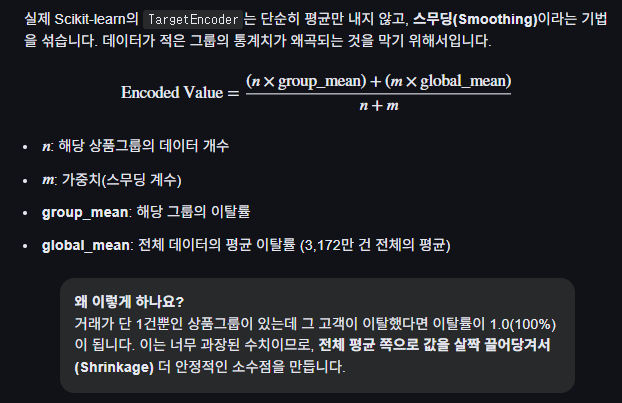

In [6]:
# 계산 방식: 해당 카테고리(상품군 등)의 평균 이탈률을 계산합니다.
# 의미: 만약 특정 카테고리의 값이 0.15라면, "이 상품을 산 사람들의 15%가 이탈했다"는 뜻
# 지금 보고 계신 소수점은 "해당 상품그룹이 가진 이탈 위험도(확률)"라고 이해하시면 됩니다.
# 0.05라면: 이 그룹은 이탈률이 5%로 낮음 (안정적)
# 0.45라면: 이 그룹은 이탈률이 45%로 매우 높음 (주의 필요)

from sklearn.preprocessing import TargetEncoder

# 과적합 방지를 위해 'smooth' 옵션을 사용
encoder = TargetEncoder(smooth="auto")
df['상품군_라벨인코딩_전체고객이탈율'] = encoder.fit_transform(df[['상품그룹']], df['전체고객이탈여부'])
df['멤버십_라벨인코딩_전체고객이탈율'] = encoder.fit_transform(df[['멤버십상태']], df['전체고객이탈여부'])
df['연령대_라벨인코딩_전체고객이탈율'] = encoder.fit_transform(df[['연령대']], df['전체고객이탈여부'])
df['구매연도_라벨인코딩_전체고객이탈율'] = encoder.fit_transform(df[['연']], df['전체고객이탈여부'])
df['구매월_라벨인코딩_전체고객이탈율'] = encoder.fit_transform(df[['월']], df['전체고객이탈여부'])

df['멤버십_라벨인코딩_신규고객이탈율'] = encoder.fit_transform(df[['상품그룹']], df['신규고객이탈'])
df['상품군_라벨인코딩_신규고객이탈율'] = encoder.fit_transform(df[['상품그룹']], df['신규고객이탈'])
df['연령대_라벨인코딩_신규고객이탈율'] = encoder.fit_transform(df[['연령대']], df['신규고객이탈'])
df['구매연도_라벨인코딩_신규고객이탈율'] = encoder.fit_transform(df[['연']], df['신규고객이탈'])
df['구매월_라벨인코딩_신규고객이탈율'] = encoder.fit_transform(df[['월']], df['신규고객이탈'])



In [7]:
df

,고객ID,패션뉴스구독여부,멤버십상태,뉴스레터수신빈도,연령,구매일,구매금액,상품그룹,연령대,거래날짜,...,상품군_라벨인코딩_전체고객이탈율,멤버십_라벨인코딩_전체고객이탈율,연령대_라벨인코딩_전체고객이탈율,구매연도_라벨인코딩_전체고객이탈율,구매월_라벨인코딩_전체고객이탈율,멤버십_라벨인코딩_신규고객이탈율,상품군_라벨인코딩_신규고객이탈율,연령대_라벨인코딩_신규고객이탈율,구매연도_라벨인코딩_신규고객이탈율,구매월_라벨인코딩_신규고객이탈율
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,30대,2018-12-27,...,0.174731,0.166809,0.181992,0.220227,0.170228,0.004100,0.004102,0.003672,0.006594,0.006219
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,30대,2018-12-27,...,0.174731,0.166808,0.182020,0.220227,0.170229,0.004096,0.004109,0.003671,0.006538,0.006231
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,30대,2018-12-27,...,0.174616,0.166810,0.182138,0.220227,0.170311,0.004096,0.004105,0.003656,0.006557,0.006181
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,30대,2019-05-02,...,0.154291,0.166794,0.182182,0.158992,0.168420,0.005006,0.005021,0.003656,0.003532,0.002990
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,30대,2019-05-25,...,0.174616,0.166794,0.182063,0.159048,0.168758,0.004112,0.004109,0.003656,0.003523,0.002990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31726154,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-09,0.043203,Garment Full body,10대 미만,2020-04-09,...,0.154335,0.166808,0.297540,0.184327,0.184224,0.005006,0.005032,0.016893,0.003971,0.003678
31726155,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-09,0.013542,Garment Upper body,10대 미만,2020-04-09,...,0.174731,0.166808,0.298106,0.184311,0.184224,0.004096,0.004105,0.016918,0.003975,0.003703
31726156,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-25,0.050831,Garment Full body,10대 미만,2020-04-25,...,0.154291,0.166813,0.298106,0.184327,0.184224,0.005043,0.005017,0.016918,0.003975,0.003725
31726157,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-06-22,0.016932,Underwear,10대 미만,2020-06-22,...,0.193136,0.166809,0.297941,0.184311,0.169899,0.002755,0.002774,0.016893,0.003975,0.002462


### total_customer_churn (전체고객 이탈 데이터)

In [8]:
total_customer_churn =  df[['고객ID','API ratio', '전체고객_최근구매경과일(R)', '전체고객_총구매횟수(F)', '전체고객_총구매금액(M)','상품군_라벨인코딩_전체고객이탈율'
                            ,'멤버십_라벨인코딩_전체고객이탈율', '연령대_라벨인코딩_전체고객이탈율', '구매연도_라벨인코딩_전체고객이탈율','구매월_라벨인코딩_전체고객이탈율','전체고객이탈여부']]

In [9]:
total_customer_churn.head(50)

,고객ID,API ratio,전체고객_최근구매경과일(R),전체고객_총구매횟수(F),전체고객_총구매금액(M),상품군_라벨인코딩_전체고객이탈율,멤버십_라벨인코딩_전체고객이탈율,연령대_라벨인코딩_전체고객이탈율,구매연도_라벨인코딩_전체고객이탈율,구매월_라벨인코딩_전체고객이탈율,전체고객이탈여부
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.174731,0.166809,0.181992,0.220227,0.170228,0
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.174731,0.166808,0.182020,0.220227,0.170229,0
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.174616,0.166810,0.182138,0.220227,0.170311,0
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.154291,0.166794,0.182182,0.158992,0.168420,0
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.174616,0.166794,0.182063,0.159048,0.168758,0
5,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.174703,0.166794,0.181992,0.159066,0.168586,0
6,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.174717,0.166809,0.182020,0.158992,0.169683,0
7,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.175908,0.166813,0.182020,0.159066,0.169503,0
8,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.175926,0.166813,0.182020,0.159048,0.190193,0
9,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.174616,0.166809,0.182063,0.158992,0.190193,0


In [ ]:
tc_churn = (
    total_customer_churn.groupby('고객ID').agg(
        API_ratio_mean =('API ratio', 'first'), #이미집계된 가격은 first
        전체고객_최근구매경과일_R = ('전체고객_최근구매경과일(R)', 'first'),
        전체고객_총구매횟수_F=('전체고객_총구매횟수(F)', 'first'),
        전체고객_총구매금액_M=('전체고객_총구매금액(M)', 'first'),
        상품군_라벨인코딩_전체고객이탈율=('상품군_라벨인코딩_전체고객이탈율', 'mean'),
        멤버십_라벨인코딩_전체고객이탈율=('멤버십_라벨인코딩_전체고객이탈율', 'mean'),
        연령대_라벨인코딩_전체고객이탈율=('연령대_라벨인코딩_전체고객이탈율', 'mean'),
        구매연도_라벨인코딩_전체고객이탈율=('구매연도_라벨인코딩_전체고객이탈율', 'mean'),
        구매월_라벨인코딩_전체고객이탈율=('구매월_라벨인코딩_전체고객이탈율', 'mean'),
        전체고객이탈여부 =('전체고객이탈여부', 'first'),

        ).reset_index()
)
tc_churn.to_csv('../../data/processed/total_churn.csv',index=False)



### new_customer_churn (신규 고객 이탈 데이터) - 1,356,227

In [11]:
new_customer_churn =  df[['고객ID','API ratio', '신규고객_최근구매경과일(R)','신규고객_총구매횟수(F)', '신규고객_총구매금액(M)',  '멤버십_라벨인코딩_신규고객이탈율', '상품군_라벨인코딩_신규고객이탈율',
       '연령대_라벨인코딩_신규고객이탈율', '구매연도_라벨인코딩_신규고객이탈율', '구매월_라벨인코딩_신규고객이탈율', '신규고객이탈']]

In [ ]:
new_churn = (
    new_customer_churn.groupby('고객ID').agg(
        API_ratio_mean =('API ratio', 'first'), #이미집계된 가격은 first
        신규고객_최근구매경과일_R = ('신규고객_최근구매경과일(R)', 'first'),
        신규고객_총구매횟수_F=('신규고객_총구매횟수(F)', 'first'),
        신규고객_총구매금액_M=('신규고객_총구매금액(M)', 'first'),
        상품군_라벨인코딩_신규고객이탈율=('상품군_라벨인코딩_신규고객이탈율', 'mean'),
        멤버십_라벨인코딩_신규고객이탈율=('멤버십_라벨인코딩_신규고객이탈율', 'mean'),
        연령대_라벨인코딩_신규고객이탈율=('연령대_라벨인코딩_신규고객이탈율', 'mean'),
        구매연도_라벨인코딩_신규고객이탈율=('구매연도_라벨인코딩_신규고객이탈율', 'mean'),
        구매월_라벨인코딩_신규고객이탈율=('구매월_라벨인코딩_신규고객이탈율', 'mean'),
        신규고객이탈여부 =('신규고객이탈', 'first'),

        ).reset_index()
)
new_churn.to_csv('../../data/processed/new_churn.csv',index=False)

In [13]:
new_churn

,고객ID,API_ratio_mean,신규고객_최근구매경과일_R,신규고객_총구매횟수_F,신규고객_총구매금액_M,상품군_라벨인코딩_신규고객이탈율,멤버십_라벨인코딩_신규고객이탈율,연령대_라벨인코딩_신규고객이탈율,구매연도_라벨인코딩_신규고객이탈율,구매월_라벨인코딩_신규고객이탈율,신규고객이탈여부
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,68.666667,17,21,0.648983,0.004277,0.004277,0.003662,0.004088,0.004729,0
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,29.818182,76,86,2.601932,0.003642,0.003645,0.003452,0.003986,0.003489,0
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,121.000000,7,18,0.704780,0.003537,0.003539,0.003453,0.004378,0.004207,0
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0.000000,471,2,0.060983,0.002771,0.002770,0.004159,0.003527,0.002449,0
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,134.000000,41,13,0.469695,0.003515,0.003525,0.004143,0.004232,0.003688,0
...,...,...,...,...,...,...,...,...,...,...,...
1356222,ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...,52.200000,16,51,1.292356,0.003444,0.003426,0.003453,0.003744,0.003798,0
1356223,ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...,38.500000,35,84,1.807322,0.004250,0.004246,0.003453,0.003942,0.004085,0
1356224,ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1...,40.000000,13,45,0.788932,0.004174,0.004178,0.003454,0.004308,0.004310,0
1356225,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,26.000000,92,7,0.209203,0.004382,0.004385,0.016915,0.003972,0.003519,0
